<img src="img/logoitqv1.jpg" width="500">
<br>

# 3_1_4_var_cuantitativas

## 0.1 01PAO26-26 - Variables cuantitativas
<br>

<img src="img/python_logo.png" width="300">
<br>

*Jesús Viera* https://github.com/Vierita23/machinelearning


In [1]:
import sys
import subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "install", "numpy", "matplotlib", "scipy", "scikit-learn", "-q"],
    check=False,
)

print("Python:", sys.executable)


Python: C:\Users\Jesus\anaconda3\python.exe


In [2]:
# Creación aleatoria de datos
import numpy as np

X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)


[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


## Medidas de tendencia central


In [3]:
from scipy import stats

media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X, keepdims=False)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)


media:  -4.24375
mediana:  0.5
moda : 0.3


## Medidas de posición


In [4]:
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5 * RIC
lim_sup = Q3 + 1.5 * RIC
print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)


RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


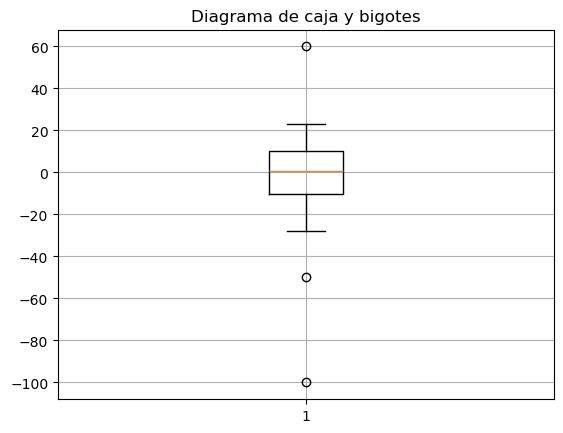

In [5]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()


## Medidas de dispersión


In [6]:
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)


Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


## Medidas de distribución


In [7]:
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True)
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))
if curtosis > 0:
    print('Distribución Leptocúrtica')
elif curtosis < 0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')


Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


## Dataset Iris


In [8]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint

iris = datasets.load_iris()
pprint(iris)
X_iris = iris.data
y = iris.target


{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

In [9]:
# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
asim_petal = stats.skew(X_iris[:, 2])
print(f"Asimetría (longitud del pétalo): {np.round(asim_petal, 4)}")
if asim_petal < 0:
    print("La variable presenta una asimetría negativa (sesgo hacia la izquierda).")
elif asim_petal > 0:
    print("La variable presenta una asimetría positiva (sesgo hacia la derecha).")
else:
    print("La variable presenta una asimetría nula (simétrica).")

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
curt_sepal = stats.kurtosis(X_iris[:, 1], fisher=True)
print(f"Curtosis (ancho del sépalo): {np.round(curt_sepal, 4)}")
if curt_sepal > 0:
    print("La distribución es leptocúrtica.")
elif curt_sepal < 0:
    print("La distribución es platicúrtica.")
else:
    print("La distribución es mesocúrtica.")


Asimetría (longitud del pétalo): -0.2721
La variable presenta una asimetría negativa (sesgo hacia la izquierda).
Curtosis (ancho del sépalo): 0.181
La distribución es leptocúrtica.


## EJERCICIO EXTRA SOBRE EL DATASET DE IRIS

Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (`plt.errorbar`)

El resultado debería ser algo como esto:


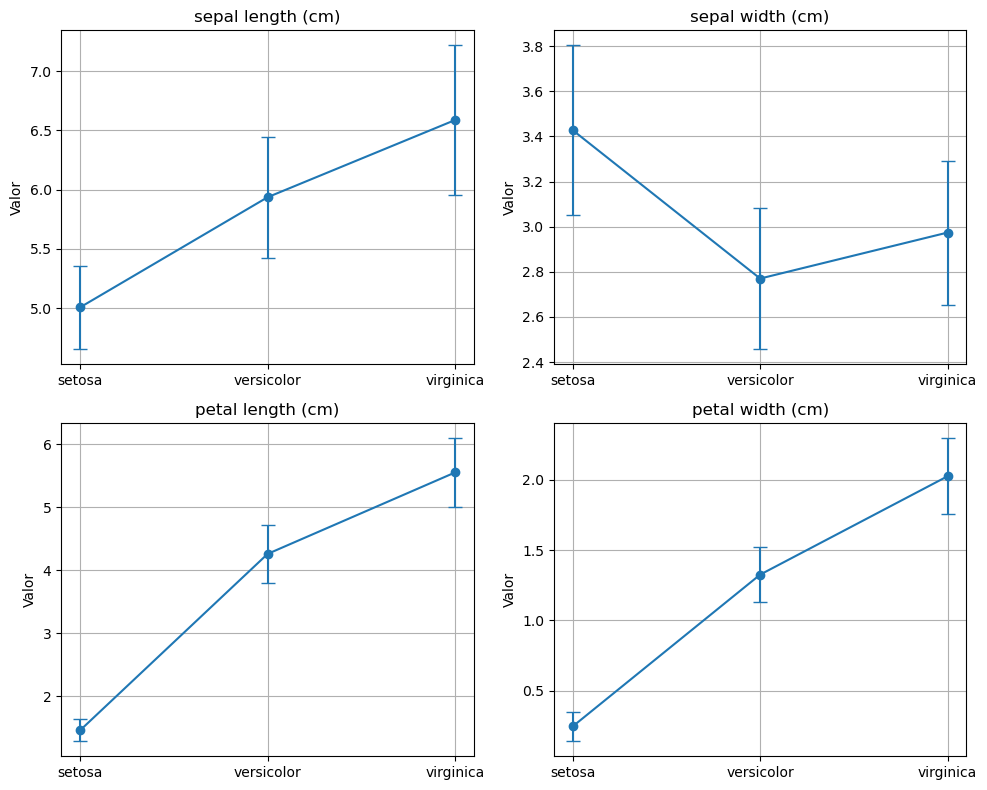

In [10]:
feature_names = iris.feature_names
target_names = iris.target_names
n_classes = len(target_names)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (ax, fname) in enumerate(zip(axes, feature_names)):
    medias = []
    desv = []
    x_pos = np.arange(n_classes)
    for c in range(n_classes):
        datos = X_iris[y == c, i]
        medias.append(np.mean(datos))
        desv.append(np.std(datos))
    ax.errorbar(x_pos, medias, yerr=desv, fmt='o-', capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(target_names)
    ax.set_title(fname)
    ax.set_ylabel('Valor')
    ax.grid(True)

plt.tight_layout()
plt.show()
